In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/flights_clean.csv")

### Create the Monthly Cancellation Table

In [4]:
monthly_cancel = df.groupby('month').agg(
    total_flights=('month', 'count'),
    cancelled_flights=('cancelled', 'sum')
)

monthly_cancel['cancel_rate'] = (
    monthly_cancel['cancelled_flights'] / monthly_cancel['total_flights']
) * 100

monthly_cancel = monthly_cancel.reset_index()

monthly_cancel



,month,total_flights,cancelled_flights,cancel_rate
0,1,27004,521,1.929344
1,2,24951,1261,5.053906
2,3,28834,861,2.986058
3,4,28330,668,2.357924
4,5,28796,563,1.955133
5,6,28243,1009,3.572567
6,7,29425,940,3.194562
7,8,29327,486,1.657176
8,9,27574,452,1.639225
9,10,28889,236,0.816920


### Line Chart

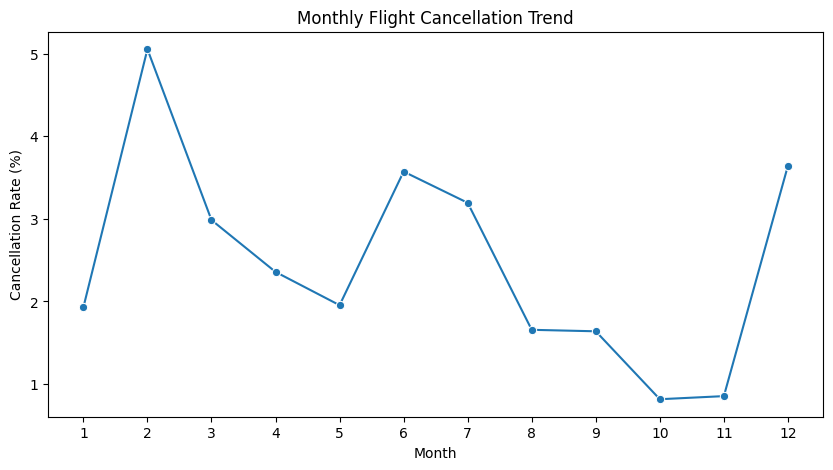

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(
    x='month',
    y='cancel_rate',
    data=monthly_cancel,
    marker='o'
)

plt.title("Monthly Flight Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(range(1,13))

plt.show()

### Show Month Names Instead of Numbers

In [5]:
import calendar

monthly_cancel['month'] = monthly_cancel['month'].apply(lambda x: calendar.month_abbr[x])

### Horizontal Bar Chart – Monthly Cancellation Rate

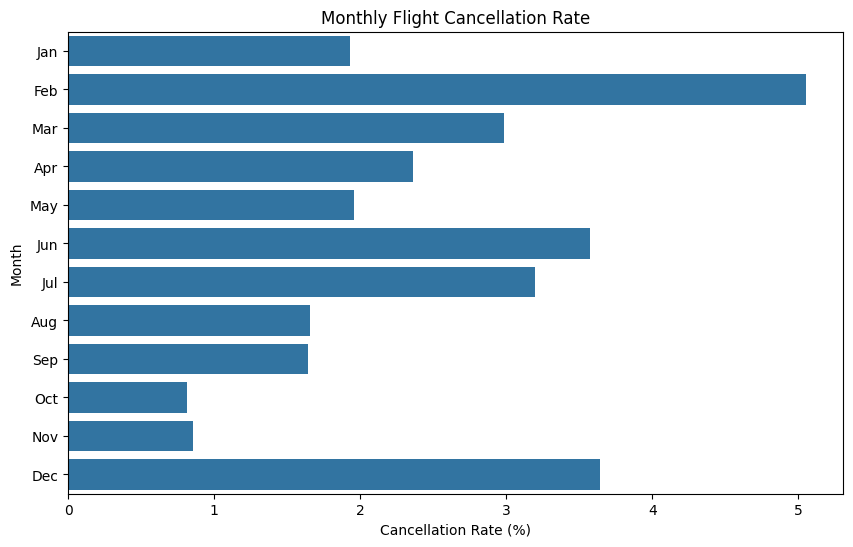

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    y='month',
    x='cancel_rate',
    data=monthly_cancel
)

plt.title("Monthly Flight Cancellation Rate")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Month")

plt.show()

### Categorize Winter vs Non-Winter Months

In [7]:
winter_months = [12, 1, 2]

df['season'] = df['month'].apply(
    lambda x: 'Winter' if x in winter_months else 'Non-Winter'
)

### Calculate Cancellation Rate by Season

In [8]:
season_cancel = df.groupby('season').agg(
    total_flights=('month','count'),
    cancelled_flights=('cancelled','sum')
)

season_cancel['cancel_rate'] = (
    season_cancel['cancelled_flights'] /
    season_cancel['total_flights']
) * 100

season_cancel = season_cancel.reset_index()

season_cancel

,season,total_flights,cancelled_flights,cancel_rate
0,Non-Winter,256686,5448,2.122438
1,Winter,80090,2807,3.504807


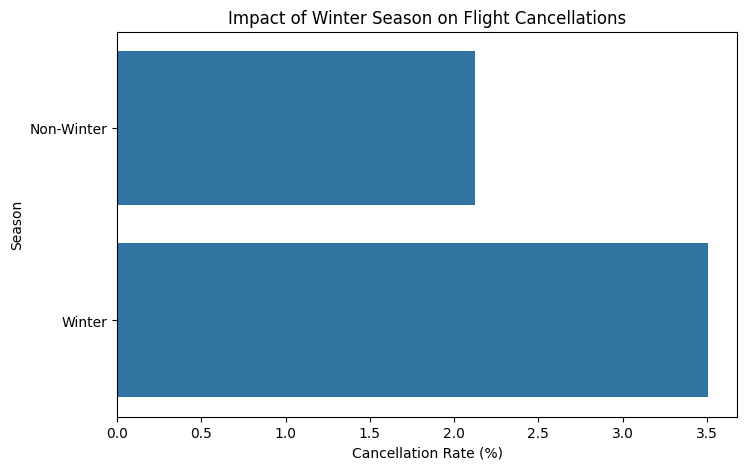

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    y='season',
    x='cancel_rate',
    data=season_cancel
)

plt.title("Impact of Winter Season on Flight Cancellations")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Season")

plt.show()

In [10]:
for col in df.columns:
    print(col)

id
year
month
day
dep_time
sched_dep_time
dep_delay
arr_time
sched_arr_time
arr_delay
carrier
flight
tailnum
origin
dest
air_time
distance
hour
minute
time_hour
name
flight_date
day_of_week
route
cancelled
on_time
season
